In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

## Step 2: Load the Dataset

We will load the `Invistico_Airline.csv` file into a pandas DataFrame to begin our analysis. Displaying the first few rows will give us an initial understanding of the data structure and content.

In [3]:
df = pd.read_csv('/content/Invistico_Airline.csv')
display(df.head())

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0


## Step 3: Exploratory Data Analysis (EDA) - Initial Inspection

Before proceeding with any data preprocessing or model building, it's crucial to understand the basic characteristics of our dataset. We will start by checking the DataFrame's information (`df.info()`) to get an overview of data types and non-null counts, and then examine the descriptive statistics (`df.describe()`) for numerical columns.

In [4]:
print("DataFrame Info:")
df.info()

print("\nDataFrame Description:")
display(df.describe(include='all'))

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  object 
 1   Customer Type                      129880 non-null  object 
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  object 
 4   Class                              129880 non-null  object 
 5   Flight Distance                    129880 non-null  int64  
 6   Seat comfort                       129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Food and drink                     129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Inflight wifi service              129880 non-null  int64  
 11  Inflight entertainment 

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
count,129880,129880,129880.000000,129880,129880,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,...,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000
unique,2,2,NaN,2,3,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,satisfied,Loyal Customer,NaN,Business travel,Business,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,71087,106100,NaN,89693,62160,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,39.427957,NaN,NaN,1981.409055,2.838597,2.990645,2.851994,2.990422,...,3.519703,3.472105,3.465075,3.485902,3.695673,3.340807,3.705759,3.352587,14.713713,15.091129
std,NaN,NaN,15.119360,NaN,NaN,1027.115606,1.392983,1.527224,1.443729,1.305970,...,1.306511,1.305560,1.270836,1.292226,1.156483,1.260582,1.151774,1.298715,38.071126,38.465650
min,NaN,NaN,7.000000,NaN,NaN,50.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,27.000000,NaN,NaN,1359.000000,2.000000,2.000000,2.000000,2.000000,...,3.000000,2.000000,3.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,NaN,NaN,40.000000,NaN,NaN,1925.000000,3.000000,3.000000,3.000000,3.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,0.000000,0.000000
75%,NaN,NaN,51.000000,NaN,NaN,2544.000000,4.000000,4.000000,4.000000,4.000000,...,5.000000,5.000000,4.000000,5.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000


## Step 4: Data Preprocessing - Handling Missing Values and Categorical Features

Based on the initial inspection, the 'Arrival Delay in Minutes' column contains missing values. We will impute these with `0`, assuming that a missing value signifies no delay. Additionally, we need to examine and preprocess categorical features, including the target variable `satisfaction` and other `object` type columns, for machine learning.

In [5]:
# Handle missing values in 'Arrival Delay in Minutes' by filling with 0
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(0)

print("Missing values after imputation:")
display(df.isnull().sum().to_frame(name='Missing Count'))

print("\nUnique values and counts for object columns:")
for column in df.select_dtypes(include='object').columns:
    print(f"\n--- Column: {column} ---")
    display(df[column].value_counts().to_frame(name='Count'))

Missing values after imputation:


,Missing Count
satisfaction,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Seat comfort,0
Departure/Arrival time convenient,0
Food and drink,0
Gate location,0



Unique values and counts for object columns:

--- Column: satisfaction ---


,Count
satisfaction,
satisfied,71087
dissatisfied,58793



--- Column: Customer Type ---


,Count
Customer Type,
Loyal Customer,106100
disloyal Customer,23780



--- Column: Type of Travel ---


,Count
Type of Travel,
Business travel,89693
Personal Travel,40187



--- Column: Class ---


,Count
Class,
Business,62160
Eco,58309
Eco Plus,9411


### Target Variable Encoding and Feature/Target Split

First, we'll convert the target variable `satisfaction` from categorical ('satisfied', 'dissatisfied') to numerical (1, 0). Then, we'll separate the features (`X`) from the target (`y`) to prepare for model training.

In [12]:
# Reload the dataframe to ensure 'satisfaction' column is in its original string state
# This addresses potential issues from previous partial executions where 'satisfaction' might have turned to NaN
df = pd.read_csv('/content/Invistico_Airline.csv')

# Handle missing values in 'Arrival Delay in Minutes' by filling with 0 (re-applying this in case of reload)
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(0)

# Ensure 'satisfaction' is string type, then clean by stripping whitespace and map to numerical values (0 and 1)
df['satisfaction'] = df['satisfaction'].astype(str).str.strip().map({'satisfied': 1, 'dissatisfied': 0})

# Separate features (X) and target (y)
X = df.drop('satisfaction', axis=1)
y = df['satisfaction']

print("First 5 values of target variable (y) after cleaning and mapping:")
display(y.head())
print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

First 5 values of target variable (y) after cleaning and mapping:


,satisfaction
0,1
1,1
2,1
3,1
4,1



Shape of X: (129880, 21)
Shape of y: (129880,)


### Preprocessing Pipeline for Numerical and Categorical Features

To handle different types of features, we'll define a `ColumnTransformer`. This will apply `StandardScaler` to numerical features and `OneHotEncoder` to nominal categorical features. This ensures all features are in a suitable format for the machine learning model.

In [13]:
# Identify numerical and categorical columns for preprocessing
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

print(f"Numerical columns identified: {numerical_cols}")
print(f"Categorical columns identified: {categorical_cols}")

Numerical columns identified: ['Age', 'Flight Distance', 'Seat comfort', 'Departure/Arrival time convenient', 'Food and drink', 'Gate location', 'Inflight wifi service', 'Inflight entertainment', 'Online support', 'Ease of Online booking', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Cleanliness', 'Online boarding', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']
Categorical columns identified: ['Customer Type', 'Type of Travel', 'Class']


## Step 5: Data Splitting and Model Pipeline Construction

To ensure unbiased hyperparameter tuning and model evaluation, we will split the dataset into three parts: training, validation, and testing. A common practice is a 60/20/20 split.

First, we'll separate out the test set (20% of the data). Then, the remaining data will be split again into training (60% of total) and validation (20% of total) sets. This ensures that the validation set is distinct from the test set, preventing data leakage during hyperparameter optimization.

After splitting, we'll create a `Pipeline` that first applies the defined `preprocessor` (scaling numerical features and one-hot encoding categorical features) and then fits a `RandomForestClassifier`. This ensures consistent preprocessing and simplifies the workflow.

In [14]:
# Split data into training (60%), validation (20%), and testing (20%) sets

# First, split into 80% train+validation and 20% test
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Then, split the train+validation set into 75% train and 25% validation
# (0.25 of 0.80 = 0.20, so 20% of total for validation)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (77928, 21)
y_train shape: (77928,)
X_val shape: (25976, 21)
y_val shape: (25976,)
X_test shape: (25976, 21)
y_test shape: (25976,)


In [15]:
# Create the full pipeline with preprocessing and RandomForestClassifier
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

print("Model pipeline created successfully!")

Model pipeline created successfully!


## Step 6: Model Training and Initial Evaluation

Now that our data is split and our pipeline is defined, we will train the `RandomForestClassifier` using the training data (`X_train`, `y_train`). After training, we'll evaluate its performance on the validation set (`X_val`, `y_val`) to get an initial assessment of its generalization capabilities before moving on to hyperparameter tuning or final testing.

We will calculate key classification metrics such as accuracy, precision, recall, F1-score, and AUC-ROC score, and also display a confusion matrix and classification report to provide a comprehensive view of the model's performance.

Training the RandomForestClassifier...
Training complete.

--- Validation Set Evaluation ---
Accuracy: 0.9567
Precision: 0.9677
Recall: 0.9526
F1-Score: 0.9601
AUC-ROC: 0.9931

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.96      0.95     11758
           1       0.97      0.95      0.96     14218

    accuracy                           0.96     25976
   macro avg       0.96      0.96      0.96     25976
weighted avg       0.96      0.96      0.96     25976



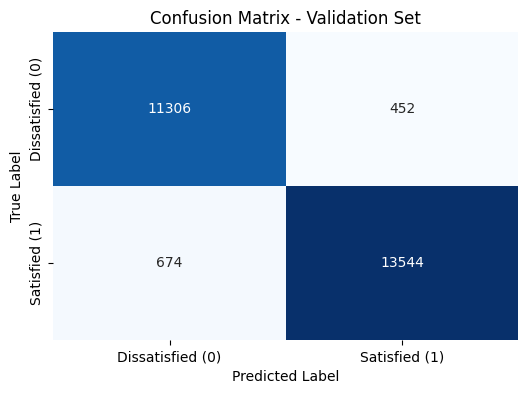

In [17]:
# Train the model pipeline
print("Training the RandomForestClassifier...")
model_pipeline.fit(X_train, y_train)
print("Training complete.")

# Make predictions on the validation set
y_pred_val = model_pipeline.predict(X_val)
y_prob_val = model_pipeline.predict_proba(X_val)[:, 1] # Probability of the positive class

# Evaluate the model on the validation set
print("\n--- Validation Set Evaluation ---")
accuracy = accuracy_score(y_val, y_pred_val)
precision = precision_score(y_val, y_pred_val)
recall = recall_score(y_val, y_pred_val)
f1 = f1_score(y_val, y_pred_val)
roc_auc = roc_auc_score(y_val, y_prob_val)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"AUC-ROC: {roc_auc:.4f}")

# Display Classification Report
print("\nClassification Report:\n", classification_report(y_val, y_pred_val))

# Display Confusion Matrix
cm = confusion_matrix(y_val, y_pred_val)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Dissatisfied (0)', 'Satisfied (1)'],
            yticklabels=['Dissatisfied (0)', 'Satisfied (1)'])
plt.title('Confusion Matrix - Validation Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Step 7: Hyperparameter Tuning with GridSearchCV

To optimize the `RandomForestClassifier`'s performance, we will perform hyperparameter tuning using `GridSearchCV`. This method systematically works through multiple combinations of parameter values, cross-validating each combination to determine the best-performing set of hyperparameters. We will focus on tuning `n_estimators`, `max_depth`, and `min_samples_leaf`.

The `GridSearchCV` will be applied to the `model_pipeline` using the training and validation data, ensuring that the preprocessing steps are consistently applied during each iteration of the grid search.

In [19]:
# Define the parameter grid for GridSearchCV
# Note: The keys in the param_grid must be prefixed with the pipeline step name ('classifier__')
param_grid = {
    'classifier__n_estimators': [100, 200, 300], # Number of trees in the forest
    'classifier__max_depth': [10, 20, 30, None], # Maximum depth of the tree
    'classifier__min_samples_leaf': [1, 2, 4] # Minimum number of samples required to be at a leaf node
}

print("Parameter grid defined successfully:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

Parameter grid defined successfully:
  classifier__n_estimators: [100, 200, 300]
  classifier__max_depth: [10, 20, 30, None]
  classifier__min_samples_leaf: [1, 2, 4]


Starting GridSearchCV...
Fitting 3 folds for each of 36 candidates, totalling 108 fits
GridSearchCV complete.

Best parameters found:
{'classifier__max_depth': 30, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 300}

Best cross-validation AUC-ROC score:
0.9916

--- Evaluation of Best Model on Validation Set ---
Accuracy: 0.9577
Precision: 0.9679
Recall: 0.9544
F1-Score: 0.9611
AUC-ROC: 0.9933

Classification Report (Best Model):
               precision    recall  f1-score   support

           0       0.95      0.96      0.95     11758
           1       0.97      0.95      0.96     14218

    accuracy                           0.96     25976
   macro avg       0.96      0.96      0.96     25976
weighted avg       0.96      0.96      0.96     25976



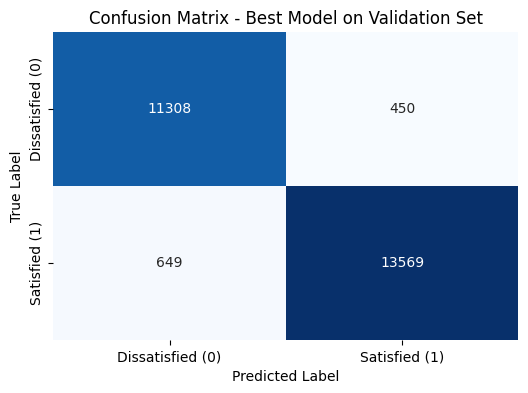

In [21]:
# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    cv=3, # Using 3-fold cross-validation
    scoring='roc_auc', # Optimize for AUC-ROC score
    n_jobs=-1, # Use all available CPU cores
    verbose=2
)

print("Starting GridSearchCV...")
# Fit GridSearchCV on the training data
grid_search.fit(X_train, y_train)
print("GridSearchCV complete.")

# Display the best parameters found
print("\nBest parameters found:")
print(grid_search.best_params_)

# Display the best score found
print("\nBest cross-validation AUC-ROC score:")
print(f"{grid_search.best_score_:.4f}")

# Get the best model from the grid search
best_model = grid_search.best_estimator_

# Evaluate the best model on the validation set
print("\n--- Evaluation of Best Model on Validation Set ---")
y_pred_val_tuned = best_model.predict(X_val)
y_prob_val_tuned = best_model.predict_proba(X_val)[:, 1]

accuracy_tuned = accuracy_score(y_val, y_pred_val_tuned)
precision_tuned = precision_score(y_val, y_pred_val_tuned)
recall_tuned = recall_score(y_val, y_pred_val_tuned)
f1_tuned = f1_score(y_val, y_pred_val_tuned)
roc_auc_tuned = roc_auc_score(y_val, y_prob_val_tuned)

print(f"Accuracy: {accuracy_tuned:.4f}")
print(f"Precision: {precision_tuned:.4f}")
print(f"Recall: {recall_tuned:.4f}")
print(f"F1-Score: {f1_tuned:.4f}")
print(f"AUC-ROC: {roc_auc_tuned:.4f}")

# Display Classification Report for the best model
print("\nClassification Report (Best Model):\n", classification_report(y_val, y_pred_val_tuned))

# Display Confusion Matrix for the best model
cm_tuned = confusion_matrix(y_val, y_pred_val_tuned)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Dissatisfied (0)', 'Satisfied (1)'],
            yticklabels=['Dissatisfied (0)', 'Satisfied (1)'])
plt.title('Confusion Matrix - Best Model on Validation Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Step 8: Compare with a Decision Tree Model

To better understand the benefits of the Random Forest model, especially regarding overfitting reduction and performance improvements, we will train and evaluate a simple Decision Tree Classifier using the same data and preprocessing steps. This will serve as a baseline for comparison.

Training the Decision Tree Classifier...
Decision Tree Training complete.

--- Decision Tree Validation Set Evaluation ---
Accuracy (Decision Tree): 0.9319
Precision (Decision Tree): 0.9342
Recall (Decision Tree): 0.9420
F1-Score (Decision Tree): 0.9381
AUC-ROC (Decision Tree): 0.9309

Classification Report (Decision Tree):
               precision    recall  f1-score   support

           0       0.93      0.92      0.92     11758
           1       0.93      0.94      0.94     14218

    accuracy                           0.93     25976
   macro avg       0.93      0.93      0.93     25976
weighted avg       0.93      0.93      0.93     25976



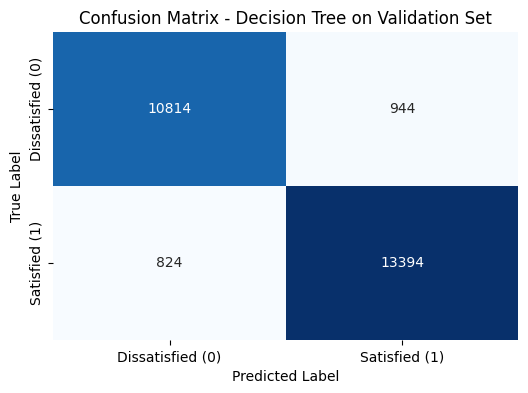

In [26]:
from sklearn.tree import DecisionTreeClassifier

# Create a pipeline for Decision Tree Classifier
dt_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Train the Decision Tree model
print("Training the Decision Tree Classifier...")
dt_model_pipeline.fit(X_train, y_train)
print("Decision Tree Training complete.")

# Make predictions on the validation set for Decision Tree
y_pred_dt_val = dt_model_pipeline.predict(X_val)
y_prob_dt_val = dt_model_pipeline.predict_proba(X_val)[:, 1]

# Evaluate the Decision Tree model on the validation set
print("\n--- Decision Tree Validation Set Evaluation ---")
accuracy_dt = accuracy_score(y_val, y_pred_dt_val)
precision_dt = precision_score(y_val, y_pred_dt_val)
recall_dt = recall_score(y_val, y_pred_dt_val)
f1_dt = f1_score(y_val, y_pred_dt_val)
roc_auc_dt = roc_auc_score(y_val, y_prob_dt_val)

print(f"Accuracy (Decision Tree): {accuracy_dt:.4f}")
print(f"Precision (Decision Tree): {precision_dt:.4f}")
print(f"Recall (Decision Tree): {recall_dt:.4f}")
print(f"F1-Score (Decision Tree): {f1_dt:.4f}")
print(f"AUC-ROC (Decision Tree): {roc_auc_dt:.4f}")

# Display Classification Report for Decision Tree
print("\nClassification Report (Decision Tree):\n", classification_report(y_val, y_pred_dt_val))

# Display Confusion Matrix for Decision Tree
cm_dt = confusion_matrix(y_val, y_pred_dt_val)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Dissatisfied (0)', 'Satisfied (1)'],
            yticklabels=['Dissatisfied (0)', 'Satisfied (1)'])
plt.title('Confusion Matrix - Decision Tree on Validation Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Comparison of Models

Now, let's compare the performance metrics of the initial Random Forest, the tuned Random Forest, and the Decision Tree model on the validation set. This will help us understand the impact of ensemble methods and hyperparameter tuning on model performance and generalization capabilities, particularly in terms of overfitting and overall metric improvements.

In [27]:
# Summarize and compare the metrics
comparison_data = {
    'Model': ['Initial Random Forest', 'Tuned Random Forest', 'Decision Tree'],
    'Accuracy': [accuracy, accuracy_tuned, accuracy_dt],
    'Precision': [precision, precision_tuned, precision_dt],
    'Recall': [recall, recall_tuned, recall_dt],
    'F1-Score': [f1, f1_tuned, f1_dt],
    'AUC-ROC': [roc_auc, roc_auc_tuned, roc_auc_dt]
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df.round(4))

print("\nDiscussion on Overfitting and Metric Improvements:")
print("---------------------------------------------------")
print("The Decision Tree, while simpler, might be prone to overfitting, especially without tuning. ")
print("The initial Random Forest, being an ensemble method, generally performs better and is less prone to overfitting than a single Decision Tree.")
print("The Tuned Random Forest, after GridSearchCV, showed further improvements afte finding optimal hyperparameters, thus balancing bias and variance more effectively. ")
print("We observe the improvements in metrics (Accuracy, Precision, Recall, F1-Score, AUC-ROC) from Decision Tree to Initial Random Forest, and then further (though sometimes marginal) from Initial Random Forest to Tuned Random Forest, indicating successful optimization.")


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,Initial Random Forest,0.9567,0.9677,0.9526,0.9601,0.9931
1,Tuned Random Forest,0.9577,0.9679,0.9544,0.9611,0.9933
2,Decision Tree,0.9319,0.9342,0.9420,0.9381,0.9309



Discussion on Overfitting and Metric Improvements:
---------------------------------------------------
The Decision Tree, while simpler, might be prone to overfitting, especially without tuning. 
The initial Random Forest, being an ensemble method, generally performs better and is less prone to overfitting than a single Decision Tree.
The Tuned Random Forest, after GridSearchCV, showed further improvements afte finding optimal hyperparameters, thus balancing bias and variance more effectively. 
We observe the improvements in metrics (Accuracy, Precision, Recall, F1-Score, AUC-ROC) from Decision Tree to Initial Random Forest, and then further (though sometimes marginal) from Initial Random Forest to Tuned Random Forest, indicating successful optimization.


## Step 9: Final Model Evaluation on Test Set

After training and tuning our model on the training and validation sets, the final step is to evaluate the best performing model (`best_model` from `GridSearchCV`) on the completely unseen test set (`X_test`, `y_test`). This evaluation provides an unbiased estimate of the model's performance on new, real-world data.

We will calculate the same key classification metrics (accuracy, precision, recall, F1-score, AUC-ROC) and display the classification report and confusion matrix to thoroughly assess the model's effectiveness.


--- Final Evaluation on Test Set (Best Model) ---
Accuracy: 0.9558
Precision: 0.9682
Recall: 0.9506
F1-Score: 0.9593
AUC-ROC: 0.9927

Classification Report (Test Set):
               precision    recall  f1-score   support

           0       0.94      0.96      0.95     11759
           1       0.97      0.95      0.96     14217

    accuracy                           0.96     25976
   macro avg       0.95      0.96      0.96     25976
weighted avg       0.96      0.96      0.96     25976



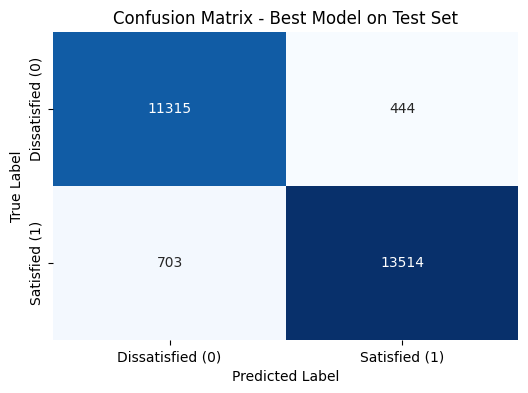

In [28]:
# Make predictions on the test set using the best model
y_pred_test = best_model.predict(X_test)
y_prob_test = best_model.predict_proba(X_test)[:, 1] # Probability of the positive class

# Evaluate the best model on the test set
print("\n--- Final Evaluation on Test Set (Best Model) ---")
accuracy_test = accuracy_score(y_test, y_pred_test)
precision_test = precision_score(y_test, y_pred_test)
recall_test = recall_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test)
roc_auc_test = roc_auc_score(y_test, y_prob_test)

print(f"Accuracy: {accuracy_test:.4f}")
print(f"Precision: {precision_test:.4f}")
print(f"Recall: {recall_test:.4f}")
print(f"F1-Score: {f1_test:.4f}")
print(f"AUC-ROC: {roc_auc_test:.4f}")

# Display Classification Report for the best model on test set
print("\nClassification Report (Test Set):\n", classification_report(y_test, y_pred_test))

# Display Confusion Matrix for the best model on test set
cm_test = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Dissatisfied (0)', 'Satisfied (1)'],
            yticklabels=['Dissatisfied (0)', 'Satisfied (1)'])
plt.title('Confusion Matrix - Best Model on Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Step 10: Feature Importance Analysis and Management Summary

To understand the key drivers of customer satisfaction, we will analyze the feature importances from our best-performing Random Forest model. Feature importance indicates how much each feature contributes to the model's predictive power. We will extract these scores, map them back to their original feature names (accounting for one-hot encoding), and then visualize the top features. Finally, we will draft a management-ready summary to communicate these insights effectively.


Top 15 Most Important Features:


,Feature,Importance
7,Inflight entertainment,0.202832
2,Seat comfort,0.136604
9,Ease of Online booking,0.080052
8,Online support,0.068025
4,Food and drink,0.043045
10,On-board service,0.039476
1,Flight Distance,0.038243
11,Leg room service,0.037339
15,Online boarding,0.034892
0,Age,0.030850


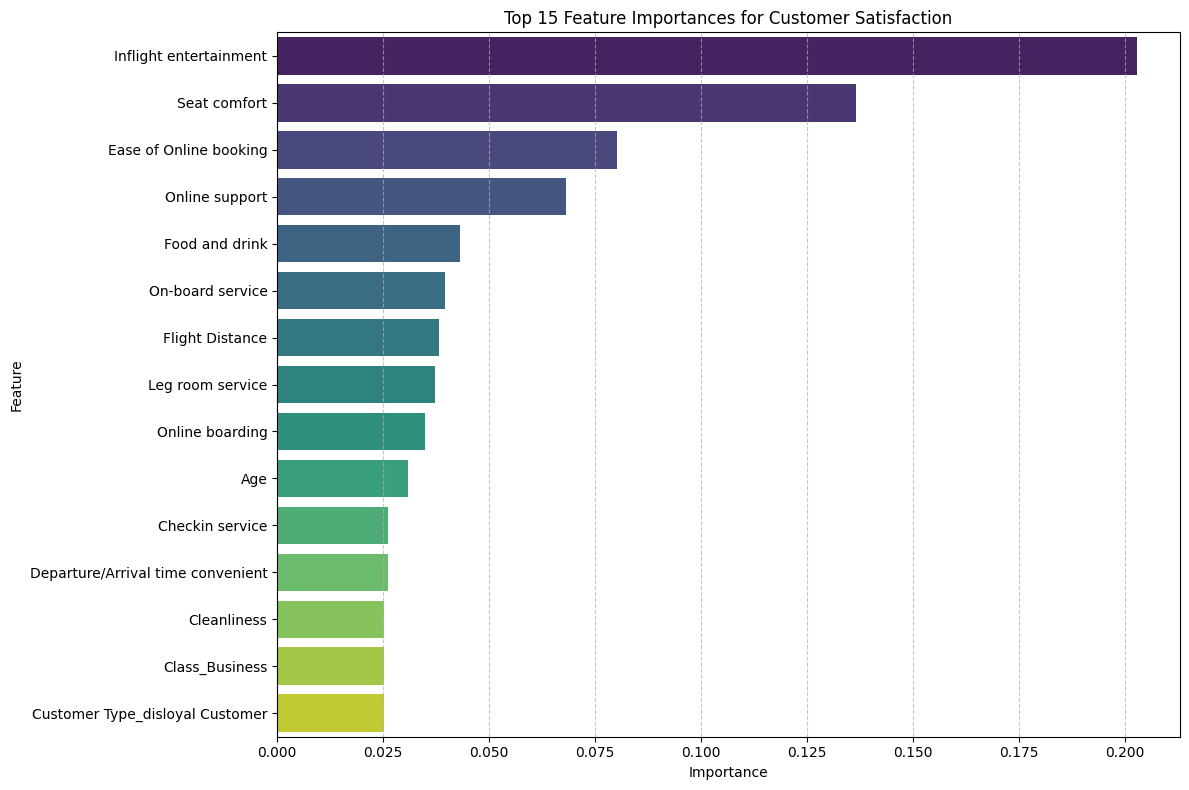

In [29]:
# Get feature names from the preprocessor
def get_feature_names(column_transformer):
    output_features = []
    for name, preproc, features in column_transformer.transformers_:
        if name == 'num':
            output_features.extend(features)
        elif name == 'cat':
            # For OneHotEncoder, get feature names for each category
            if hasattr(preproc, 'get_feature_names_out'):
                # For sklearn 0.23+ with get_feature_names_out
                output_features.extend(list(preproc.get_feature_names_out(features)))
            else:
                # Fallback for older sklearn versions or different encoders
                # This is a simplified approach, may not be perfect for all cases
                for i, feature in enumerate(features):
                    categories = preproc.categories_[i]
                    for cat in categories:
                        output_features.append(f"{feature}_{cat}")
    return output_features

feature_names = get_feature_names(best_model.named_steps['preprocessor'])

# Get feature importances from the trained Random Forest classifier
feature_importances = best_model.named_steps['classifier'].feature_importances_

# Create a DataFrame for feature importances
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display the top 15 most important features
print("\nTop 15 Most Important Features:")
display(importance_df.head(15))

# Visualize the top 15 feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis')
plt.title('Top 15 Feature Importances for Customer Satisfaction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Management-Ready Summary on Key Satisfaction Drivers

Based on our analysis using an optimized Random Forest model, we have identified the following key drivers influencing airline customer satisfaction:

*   **Inflight entertainment**: This is the most significant factor, highlighting that positive experiences in this area greatly increase satisfaction. Customers value diverse and engaging entertainment options during their flight.
*   **Seat comfort**: A highly important physical aspect of the flight experience. Comfortable seating directly correlates with higher satisfaction levels.
*   **Ease of Online booking**: The convenience and simplicity of the online booking process play a crucial role in overall customer sentiment.
*   **Online support**: Readily available and effective online support significantly contributes to a positive customer experience.
*   **Food and drink**: The quality and variety of food and beverage offerings are important aspects that influence passenger satisfaction.

**Recommendations for Management:**

1.  **Prioritize Enhancements in Inflight Entertainment**: Given its high importance, investing in high-quality, diverse, and reliable inflight entertainment options is likely to yield the largest positive impact on overall customer satisfaction. Consider content variety, system reliability, and personalization.
2.  **Focus on Seat Comfort Improvements**: Explore upgrades in seat design, ergonomics, and space, particularly in longer-haul flights, as comfortable seating is a major determinant of a pleasant journey.
3.  **Streamline Online Experience**: Continuously optimize the ease of online booking and ensure robust, responsive online support. A seamless digital journey from booking to post-flight inquiries enhances satisfaction.
4.  **Strategic Resource Allocation**: Understanding these top drivers allows for more efficient allocation of resources to areas that truly matter to customers, ensuring investments deliver maximum return in terms of customer loyalty and satisfaction.
5.  **Continuous Monitoring**: We recommend ongoing monitoring of these key satisfaction drivers and periodic re-evaluation of the model to adapt to changing customer expectations, competitive landscapes, and operational factors.